In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv("data.csv")
print(data.head())
print(data.info())


    Age   Salary  Experience Department
0  22.0  25000.0           1         IT
1  25.0  30000.0           2         HR
2   NaN  28000.0           2         IT
3  28.0      NaN           3    Finance
4  35.0  50000.0          10         IT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         8 non-null      float64
 1   Salary      8 non-null      float64
 2   Experience  10 non-null     int64  
 3   Department  10 non-null     object 
dtypes: float64(2), int64(1), object(1)
memory usage: 452.0+ bytes
None


In [5]:
print(data.isnull().sum())

Age           2
Salary        2
Experience    0
Department    0
dtype: int64


In [6]:
#(b) Removing Missing Values
data_dropped = data.dropna()

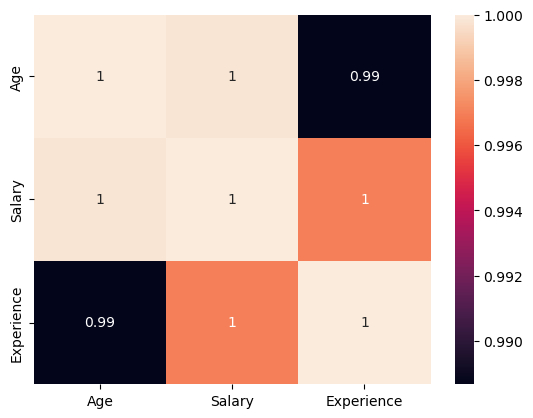

In [7]:
# Change this line
corr = data.corr(numeric_only=True)
# The rest remains the same
sns.heatmap(corr, annot=True)
plt.show()


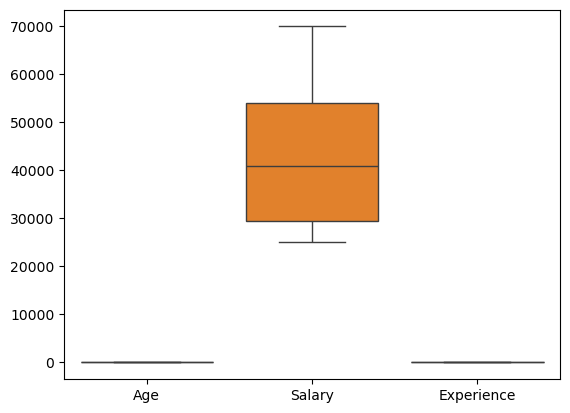

In [8]:
sns.boxplot(data=data)
plt.show()


In [9]:
# Create PerformanceIndex using available columns
data["PerformanceIndex"] = data["Experience"] * data["Salary"]


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Handle missing values
data = data.fillna(0)
# Use the columns that actually exist in your dataset
X = data[["Age", "Salary", "Experience"]]  # Features
y = data["Salary"]  # Target variable (or use another column as target)
# Split the data (90% train, 10% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
# Verify the results
print("Dataset shape:", data.shape)
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(data)*100:.0f}%)")
print(f"Testing set: {len(X_test)} samples ({len(X_test)/len(data)*100:.0f}%)")
print("\nFeatures used:", X.columns.tolist())
print("Target variable:", y.name)

Dataset shape: (10, 5)
Training set: 9 samples (90%)
Testing set: 1 samples (10%)

Features used: ['Age', 'Salary', 'Experience']
Target variable: Salary


In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Normalization
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
# Standardization
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)


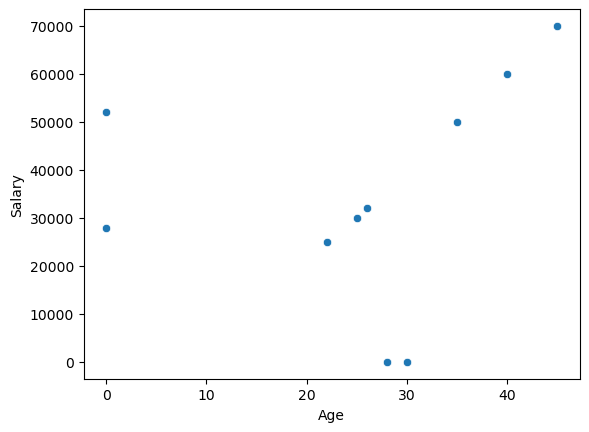

In [16]:
sns.scatterplot(x=data["Age"], y=data["Salary"])
plt.show()

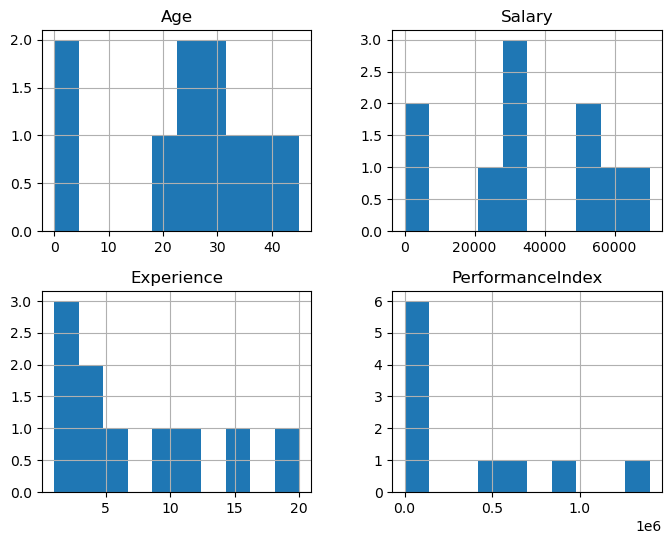

In [17]:
data.hist(figsize=(8,6))
plt.show()

In [19]:
#Implement Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)


Mean Squared Error: 1.3234889800848443e-23
